In [17]:
import pandas as pd
import os

CSV_PATH = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/geogaze_model_predictions_with_choices.csv"
#

df = pd.read_csv(CSV_PATH)

# Normalize columns (in case of spacing/capitalization issues)
df.rename(columns=lambda c: c.strip().lower(), inplace=True)

# We only care about TARGET vs everything else
df["is_target"] = (df["choice"] == "TARGET").astype(int)

# Group by model + condition → compute % TARGET
acc = (
    df.groupby(["model", "condition"])["is_target"]
      .mean()                     # mean of 0/1 = percent TARGET
      .reset_index()
)

# Pivot so each condition becomes its own column
summary = acc.pivot(index="model", columns="condition", values="is_target")

# Reorder columns so output is always consistent
desired_cols = ["train", "spatial", "featural", "conflict"]
summary = summary.reindex(columns=desired_cols)

# Convert proportions → percentages (0–100)
summary = summary * 100

# Reset index for clean CSV output
summary = summary.reset_index()

# Save output CSV
out_path = os.path.splitext(CSV_PATH)[0] + "_accuracy_summary.csv"
summary.to_csv(out_path, index=False)

print("Done. Saved summary to:\n", out_path)
summary


Done. Saved summary to:
 /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/geogaze_model_predictions_with_choices_accuracy_summary.csv


condition,model,train,spatial,featural,conflict
0,maskL_bc_bs,100.0,0.0,100.0,100.0
1,maskL_bc_gc,100.0,0.0,100.0,100.0
2,maskL_bs_bc,100.0,0.0,100.0,0.0
3,maskL_bs_gs,0.0,0.0,0.0,0.0
4,maskL_gc_bc,100.0,0.0,100.0,100.0
5,maskL_gc_gs,100.0,0.0,100.0,100.0
6,maskL_gs_bs,0.0,0.0,0.0,0.0
7,maskL_gs_gc,0.0,0.0,0.0,0.0
8,maskR_bc_bs,100.0,50.0,50.0,0.0
9,maskR_bc_gc,100.0,100.0,50.0,0.0


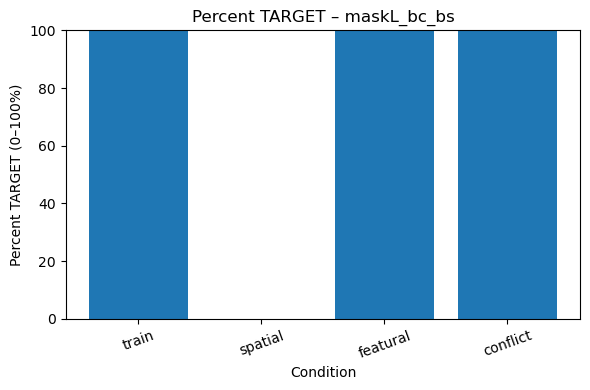

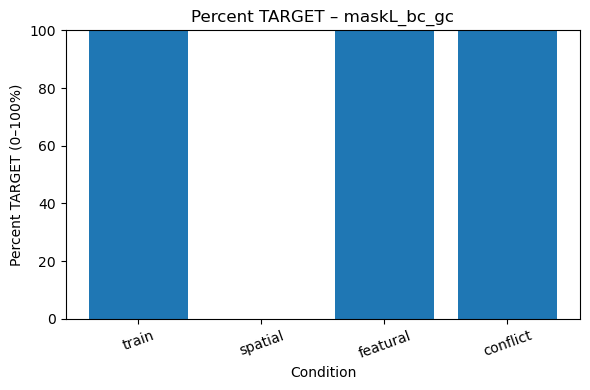

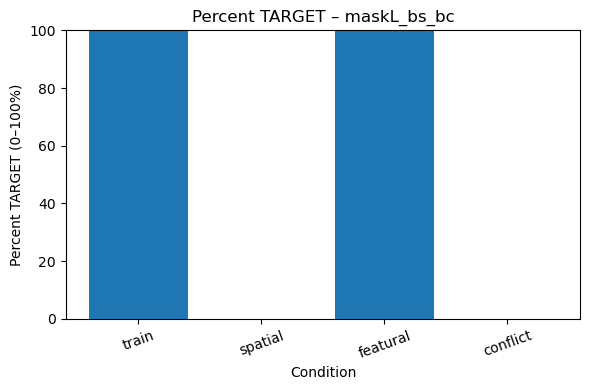

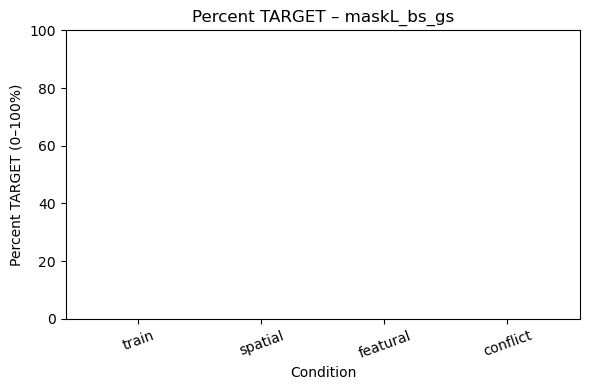

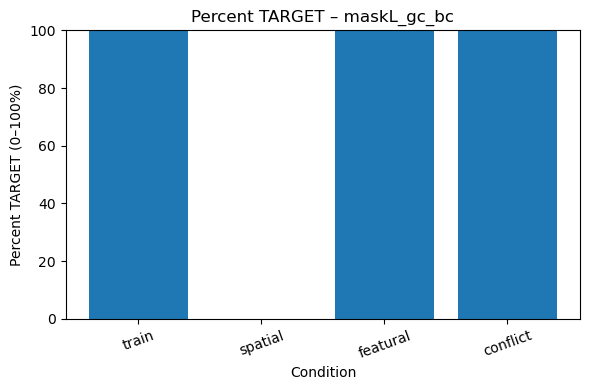

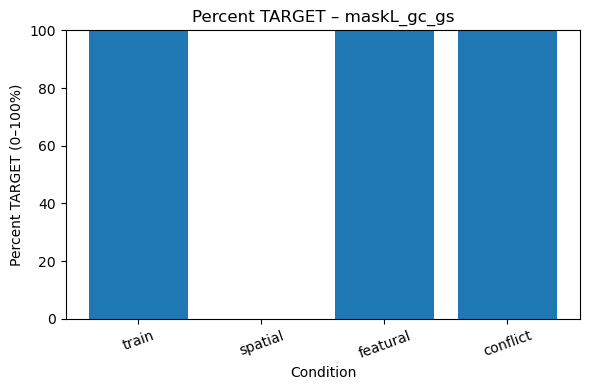

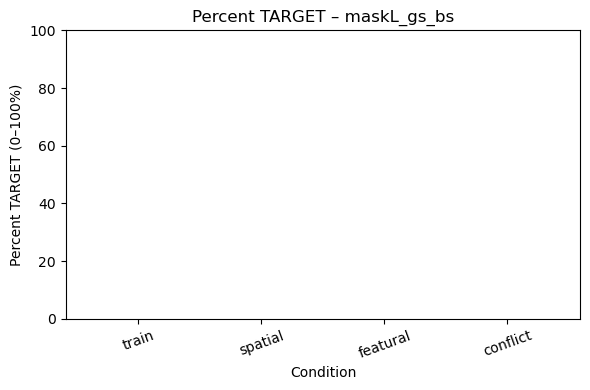

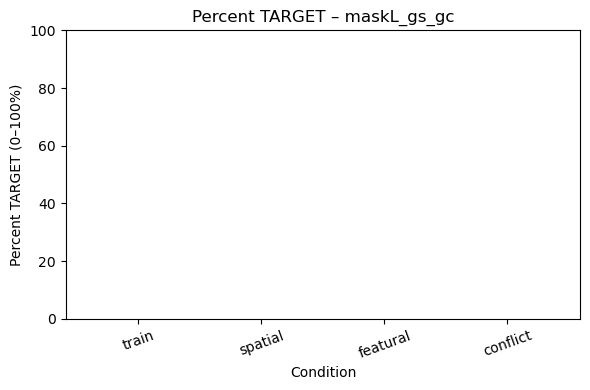

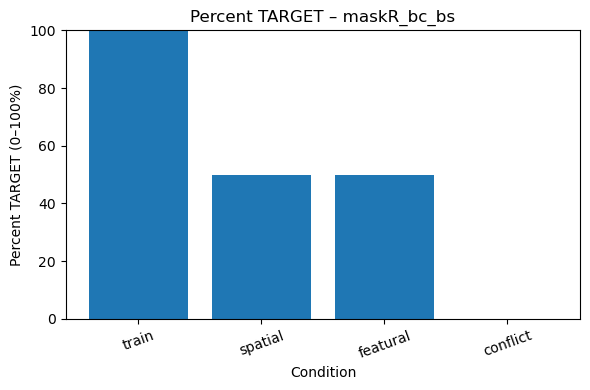

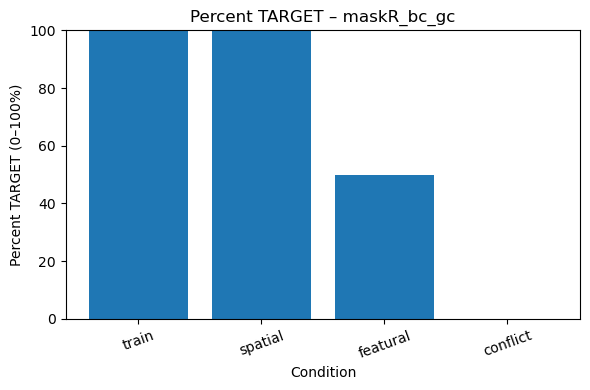

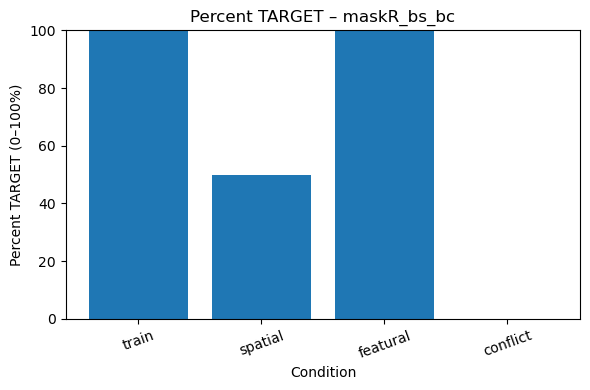

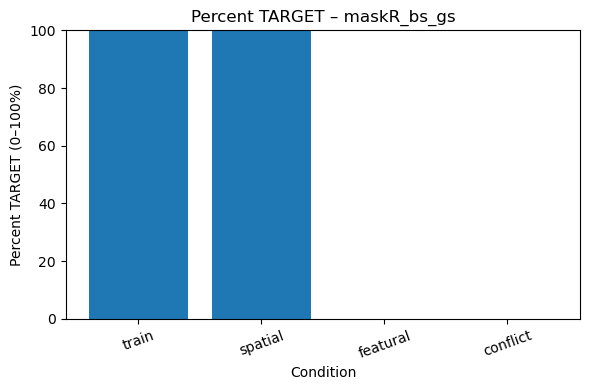

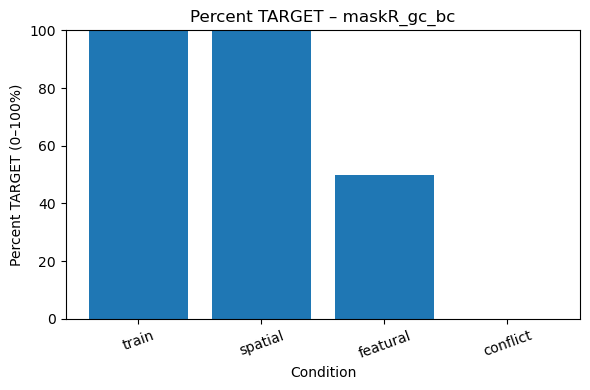

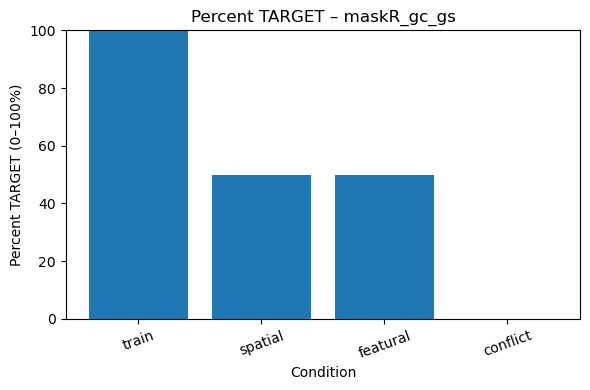

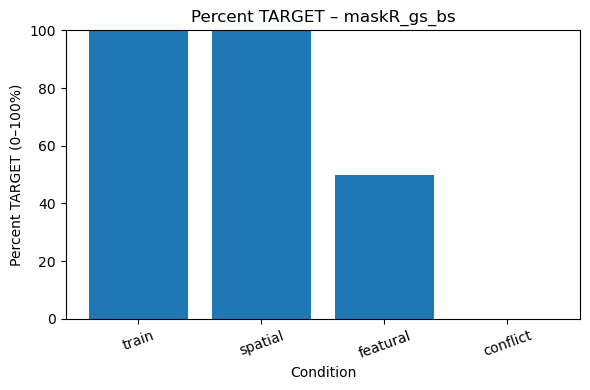

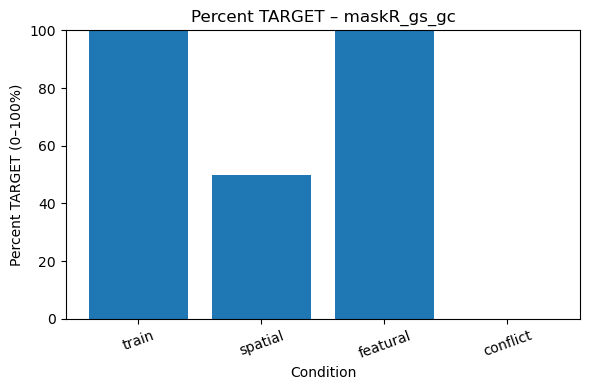

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Conditions in the order you want them on the x-axis
conditions = ["train", "spatial", "featural", "conflict"]

# Loop over models and plot one bar chart per model
for _, row in summary.iterrows():
    model = row["model"]
    
    # Get values in the right order, replacing NaN with 0
    vals = [0 if pd.isna(row[c]) else row[c] for c in conditions]

    plt.figure(figsize=(6, 4))
    plt.bar(conditions, vals)
    plt.ylim(0, 100)
    plt.title(f"Percent TARGET – {model}")
    plt.ylabel("Percent TARGET (0–100%)")
    plt.xlabel("Condition")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


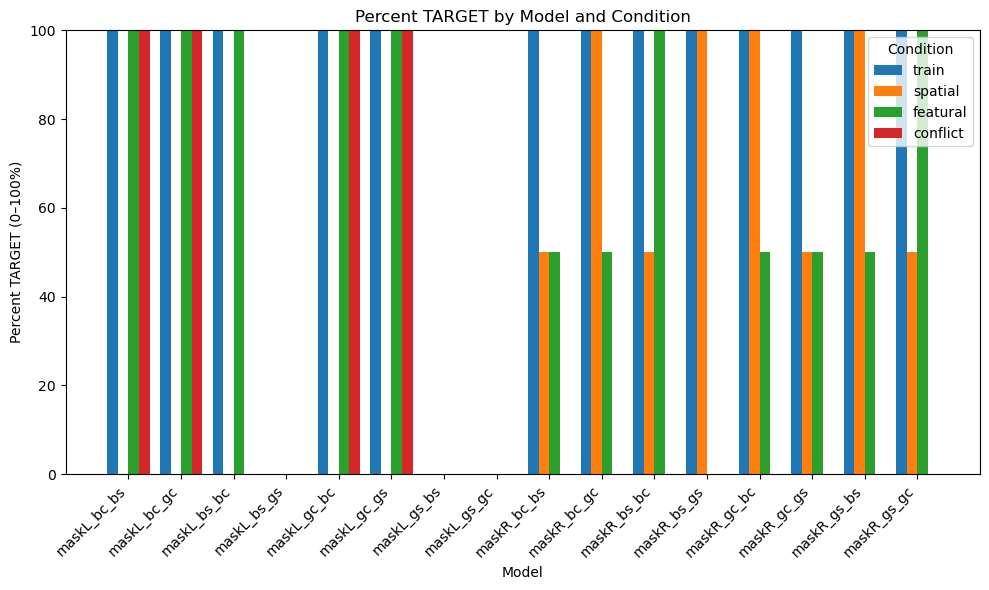

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# conditions in a fixed order
conditions = ["train", "spatial", "featural", "conflict"]

# X positions for each model
x = np.arange(len(summary))  # 0,1,2,... for each model
width = 0.2                  # width of each bar

plt.figure(figsize=(10, 6))

for i, cond in enumerate(conditions):
    # values for this condition across models (replace NaN with 0 if needed)
    vals = summary[cond].fillna(0).values
    plt.bar(x + (i - 1.5)*width, vals, width, label=cond)

plt.ylabel("Percent TARGET (0–100%)")
plt.xlabel("Model")
plt.title("Percent TARGET by Model and Condition")

# Set model names below ticks
plt.xticks(x, summary["model"], rotation=45, ha="right")

plt.ylim(0, 100)

# 🔹 Matplotlib legend in the "northeast" (upper right) of the axes
plt.legend(title="Condition", loc="upper right")

plt.tight_layout()
plt.show()



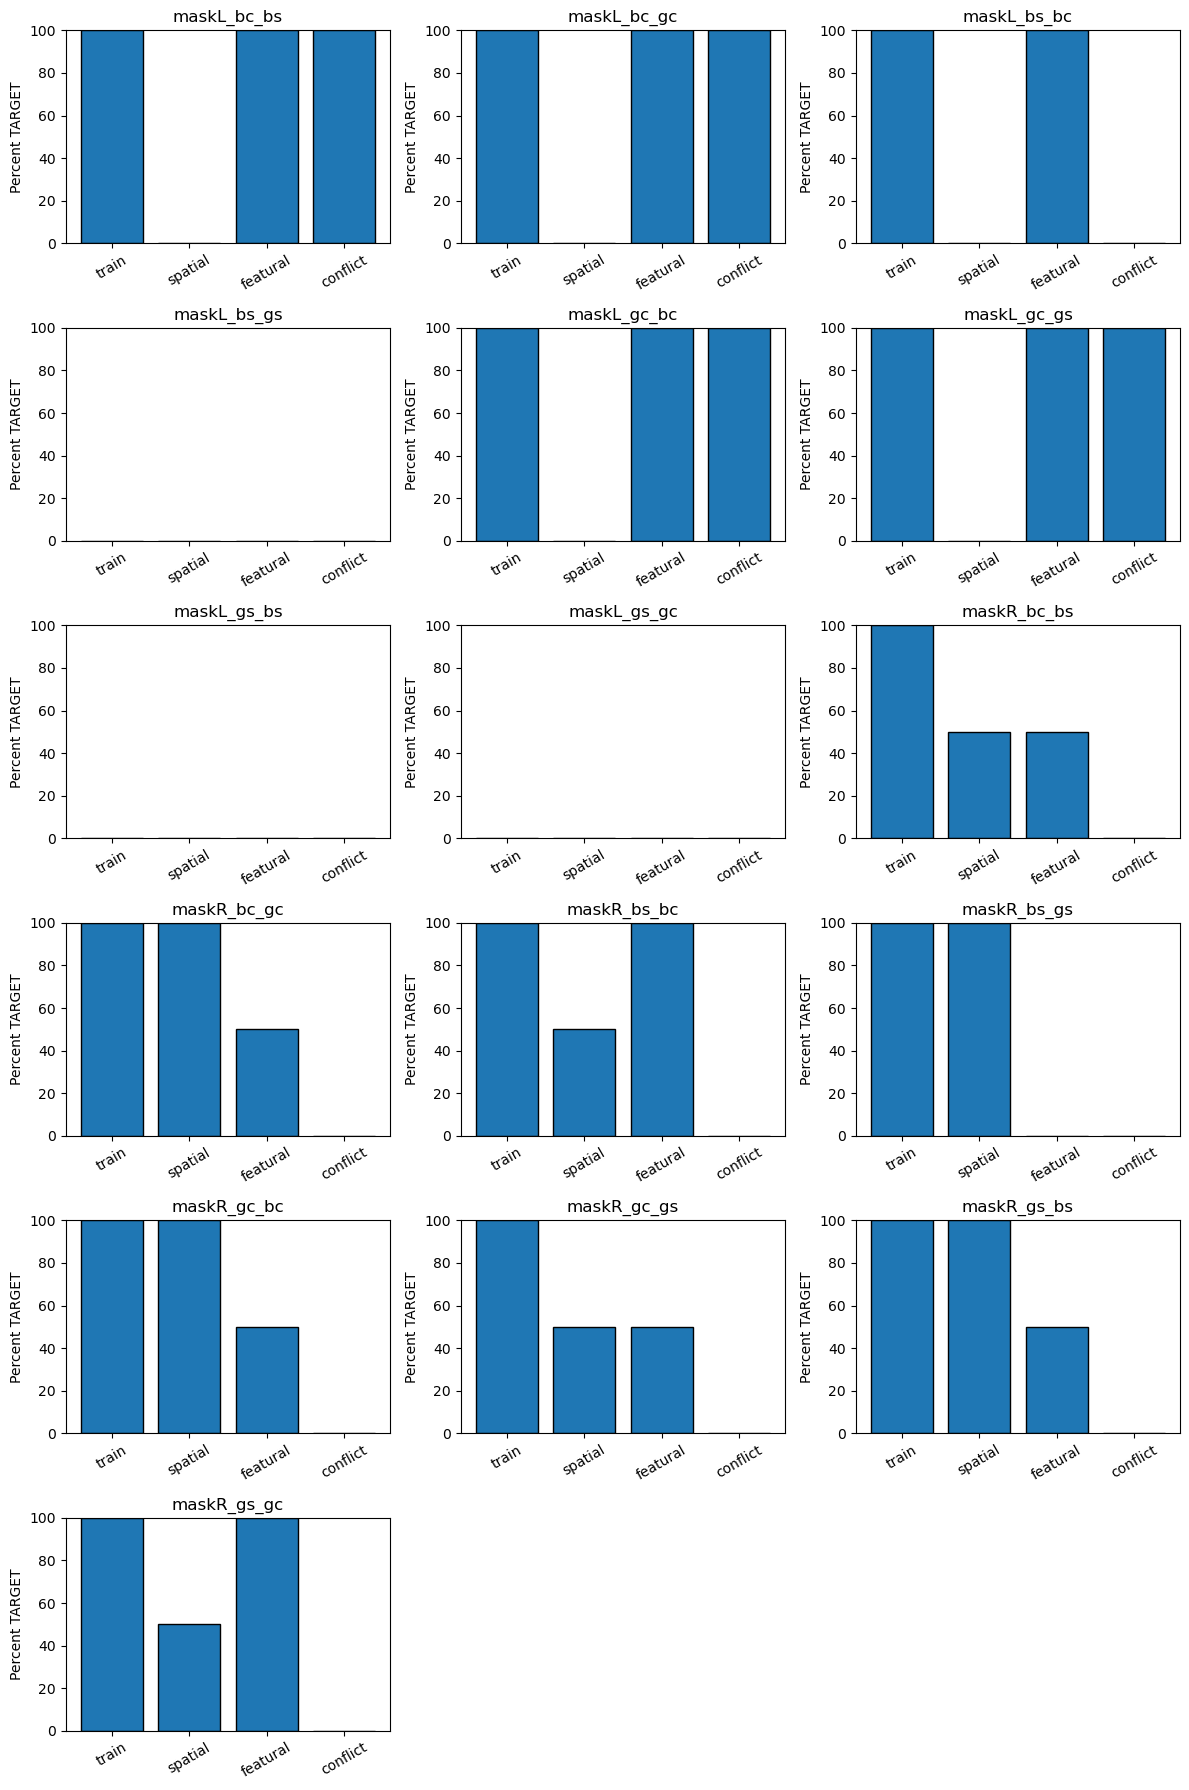

Saved PNG to: model_condition_bars.png


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# summary: columns = ['model', 'train', 'spatial', 'featural', 'contrast']
conditions = ["train", "spatial", "featural", "conflict"]
n_models = len(summary)

# layout: 3 columns of subplots
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, (_, row) in enumerate(summary.iterrows()):
    ax = axes[i]
    vals = [row[c] for c in conditions]

    ax.bar(range(len(conditions)), vals,
           edgecolor="black", linewidth=1)  # borders on bars

    ax.set_ylim(0, 100)
    ax.set_title(str(row["model"]))
    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(conditions, rotation=30)
    ax.set_ylabel("Percent TARGET")
    ax.grid(False)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# ✅ SAVE FIGURE AS PNG
output_path = "model_condition_bars.png"
plt.savefig(output_path, dpi=300)

plt.show()

print(f"Saved PNG to: {output_path}")



In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Path to your CSV with columns: model, condition, acc_continuous, ...
csv_path = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/geogaze_model_predictions_with_acc.csv"

df_long = pd.read_csv(csv_path)

# Quick sanity check
print(df_long.head())
print(df_long['condition'].value_counts())
print(df_long['model'].nunique(), "models")
print(df_long['acc_continuous'].describe())


         model condition         test_image                target  \
0  maskL_bc_bs     train  test_bc_bs_LR.png  test_left_c_mask.png   
1  maskL_bc_bs   spatial  test_bc_bc_LR.png  test_left_c_mask.png   
2  maskL_bc_bs   spatial  test_bs_bs_LR.png  test_left_s_mask.png   
3  maskL_bc_bs  featural  test_bc_bs_UD.png    test_up_c_mask.png   
4  maskL_bc_bs  featural  test_bs_bc_UD.png  test_down_c_mask.png   

              distractor                                         prediction  \
0  test_right_s_mask.png  test_bc_bs_LR__model=resnet50.a1_in1k_maskL_bc...   
1  test_right_c_mask.png  test_bc_bc_LR__model=resnet50.a1_in1k_maskL_bc...   
2  test_right_s_mask.png  test_bs_bs_LR__model=resnet50.a1_in1k_maskL_bc...   
3   test_down_s_mask.png  test_bc_bs_UD__model=resnet50.a1_in1k_maskL_bc...   
4     test_up_s_mask.png  test_bs_bc_UD__model=resnet50.a1_in1k_maskL_bc...   

   choice  acc_continuous  
0     NaN        0.645035  
1     NaN        0.469911  
2     NaN        0.500000 

In [34]:
# Conditions of interest
conds = ['train', 'spatial', 'featural', 'conflict']

# Models to exclude
exclude_models = ['maskL_bs_gs', 'maskL_gs_bs', 'maskL_gs_gc']

# 1) Filter to desired conditions and models
df_filt = df_long.query("condition in @conds and model not in @exclude_models")

# 2) Per-model mean continuous accuracy per condition
per_model = (
    df_filt
    .groupby(['model', 'condition'], as_index=False)['acc_continuous']
    .mean()
    .rename(columns={'acc_continuous': 'acc'})
)

# Optional: convert to percent (0–100) for plotting like before
per_model['acc'] = per_model['acc'] * 100

print(per_model.head())


         model condition        acc
0  maskL_bc_bs  conflict  75.201121
1  maskL_bc_bs  featural  73.186653
2  maskL_bc_bs   spatial  48.495573
3  maskL_bc_bs     train  64.503484
4  maskL_bc_gc  conflict  70.852738


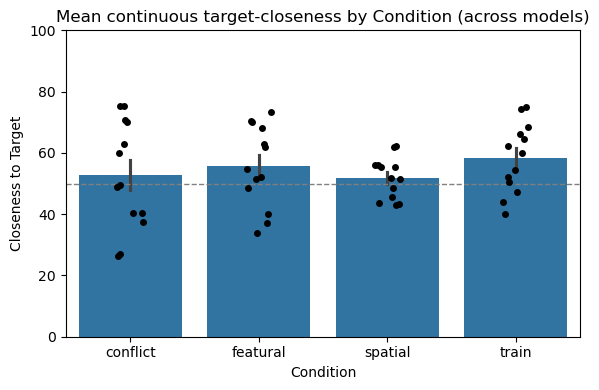

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# Bars: mean score across models for each condition
ax = sns.barplot(
    data=per_model,
    x='condition', y='acc',
    errorbar='se'
)

# Dots: each model's score in that condition
sns.stripplot(
    data=per_model,
    x='condition', y='acc',
    color='black'
)

ax.set_title("Mean continuous target-closeness by Condition (across models)")
ax.set_xlabel("Condition")
ax.set_ylabel("Closeness to Target")

plt.ylim(0, 100)

# ---- chance line (50%) ----
plt.axhline(y=50, linestyle='--', linewidth=1, color='gray')

plt.tight_layout()

# save as PNG
plt.savefig("graph2.png", dpi=300)

plt.show()
